# Train — sheep policy (behavioural cloning, no memory)

Clone the **sheep** RuleBrain into a small memoryless network:

```
grids (C,K,K) ─CNN─┐
                   ├─▶ trunk (MLP) ─▶ heading mean (2)  ─ MSE  ─▶ teacher heading
scalars (10) ─MLP──┘                 gate logits  (3)  ─ BCE  ─▶ eat / drink / repro
                                     speed logit  (1)  ─ BCE  ─▶ speed throttle
```

Same CNN front-end as the deployed brain (`sim/neural_brain.py`), but the LSTM is replaced
by a feed-forward trunk and the critic is dropped — this is supervised imitation, not RL.
We **hold out one whole world** for validation, so the reported metrics measure
generalization to a map the network never trained on.

In [1]:
import sys
from pathlib import Path
_cwd = Path.cwd()
for _c in (_cwd, _cwd / "notebooks" / "imitation_learning"):
    if (_c / "common.py").exists():
        sys.path.insert(0, str(_c)); break
import numpy as np
import matplotlib.pyplot as plt
import torch
import common as C
from config import SHEEP, FOX, SPECIES_NAMES

SID = SHEEP
device = "cuda" if torch.cuda.is_available() else "cpu"
print("species:", SPECIES_NAMES[SID], "| device:", device,
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")

species: sheep | device: cuda | NVIDIA GeForce RTX 4050 Laptop GPU


## Load the dataset

Grids stay **float16** in CPU RAM; each minibatch is sliced and moved to the GPU as float32,
so the whole dataset never has to fit in VRAM at once.

In [2]:
d = C.load_dataset(SID)
print("rows:", d['grids'].shape[0], "| grids:", d['grids'].shape[1:],
      "| worlds:", np.bincount(d['world']))
VAL_WORLD = int(d['world'].max())        # held-out validation world (last collected)

rows: 180000 | grids: (5, 57, 57) | worlds: [6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000
 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000
 6000 6000]


## Train

GPU-batched behavioural cloning. Watch `val cos` (heading cosine vs the teacher, →1 is
perfect) and the per-gate accuracies climb on the held-out world.

In [3]:
model, history = C.train_policy(SID, d, device=device, epochs=25,
                               batch_size=512, lr=1e-3, val_world=VAL_WORLD)

  gate +rates [0.58 0.17 0.41] speed +rate 0.43 -> pos_weight gates [0.7 4.7 1.5] speed 1.3
  [sheep  1/25] loss=1.9667 (head=0.9078 gate=0.7457 speed=0.6264) | val cos=0.368 eat=0.64 drink=0.77 repro=0.73 speed=0.67
  [sheep  2/25] loss=1.5758 (head=0.7751 gate=0.5983 speed=0.4047) | val cos=0.467 eat=0.68 drink=0.84 repro=0.82 speed=0.83
  [sheep  3/25] loss=1.3294 (head=0.6769 gate=0.4991 speed=0.3067) | val cos=0.535 eat=0.72 drink=0.82 repro=0.87 speed=0.87
  [sheep  4/25] loss=1.1886 (head=0.6154 gate=0.4387 speed=0.2690) | val cos=0.567 eat=0.73 drink=0.85 repro=0.89 speed=0.89
  [sheep  5/25] loss=1.1071 (head=0.5811 gate=0.4013 speed=0.2495) | val cos=0.592 eat=0.73 drink=0.91 repro=0.91 speed=0.89
  [sheep  6/25] loss=1.0471 (head=0.5587 gate=0.3729 speed=0.2311) | val cos=0.612 eat=0.73 drink=0.93 repro=0.91 speed=0.90
  [sheep  7/25] loss=1.0049 (head=0.5419 gate=0.3540 speed=0.2181) | val cos=0.593 eat=0.74 drink=0.93 repro=0.92 speed=0.91
  [sheep  8/25] loss=0.9681 (head

## Results

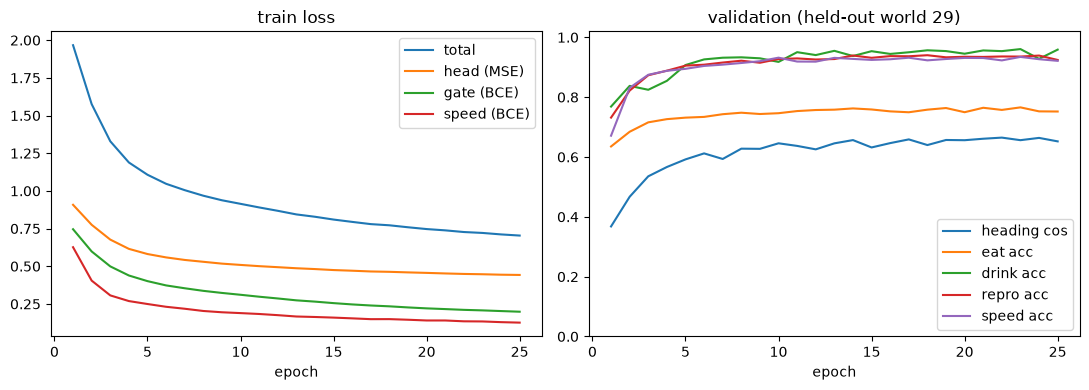

{'heading_cos': 0.652, 'eat_acc': 0.752, 'drink_acc': 0.959, 'repro_acc': 0.924, 'speed_acc': 0.921}


In [4]:
ep = [h['epoch'] for h in history]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ep, [h['tr_loss'] for h in history], label='total')
ax[0].plot(ep, [h['tr_head'] for h in history], label='head (MSE)')
ax[0].plot(ep, [h['tr_gate'] for h in history], label='gate (BCE)')
ax[0].plot(ep, [h['tr_speed'] for h in history], label='speed (BCE)')
ax[0].set_title('train loss'); ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].plot(ep, [h['heading_cos'] for h in history], label='heading cos')
ax[1].plot(ep, [h['eat_acc'] for h in history], label='eat acc')
ax[1].plot(ep, [h['drink_acc'] for h in history], label='drink acc')
ax[1].plot(ep, [h['repro_acc'] for h in history], label='repro acc')
ax[1].plot(ep, [h['speed_acc'] for h in history], label='speed acc')
ax[1].set_title(f'validation (held-out world {VAL_WORLD})')
ax[1].set_xlabel('epoch'); ax[1].set_ylim(0, 1.02); ax[1].legend()
plt.tight_layout(); plt.show()

final = history[-1]
print({k: round(final[k], 3) for k in ('heading_cos','eat_acc','drink_acc','repro_acc','speed_acc')})

## Save the model

In [5]:
path = C.save_model(SID, model, meta={'epochs': len(history),
                                          'val_world': VAL_WORLD,
                                          'final': history[-1]})
print("saved ->", path)

saved -> C:\Users\afree\Desktop\ecosystem\notebooks\imitation_learning\sheep.pt
